===== DATASET SHAPE =====
(161, 14)

===== COLUMN NAMES =====
['Product_id', 'Price', 'Sale', 'weight', 'resoloution', 'ppi', 'cpu core', 'cpu freq', 'internalmem', 'ram', 'RearCam', 'Front_Cam', 'battery', 'thickness']

===== DATA TYPES =====
Product_id       int64
Price            int64
Sale             int64
weight         float64
resoloution    float64
ppi              int64
cpu core         int64
cpu freq       float64
internalmem    float64
ram            float64
RearCam        float64
Front_Cam      float64
battery          int64
thickness      float64
dtype: object

===== MISSING VALUES =====
Product_id     0
Price          0
Sale           0
weight         0
resoloution    0
ppi            0
cpu core       0
cpu freq       0
internalmem    0
ram            0
RearCam        0
Front_Cam      0
battery        0
thickness      0
dtype: int64

===== STATISTICAL SUMMARY =====
       Product_id    Price     Sale  weight  resoloution     ppi  cpu core  \
count      161.00   161.00   1

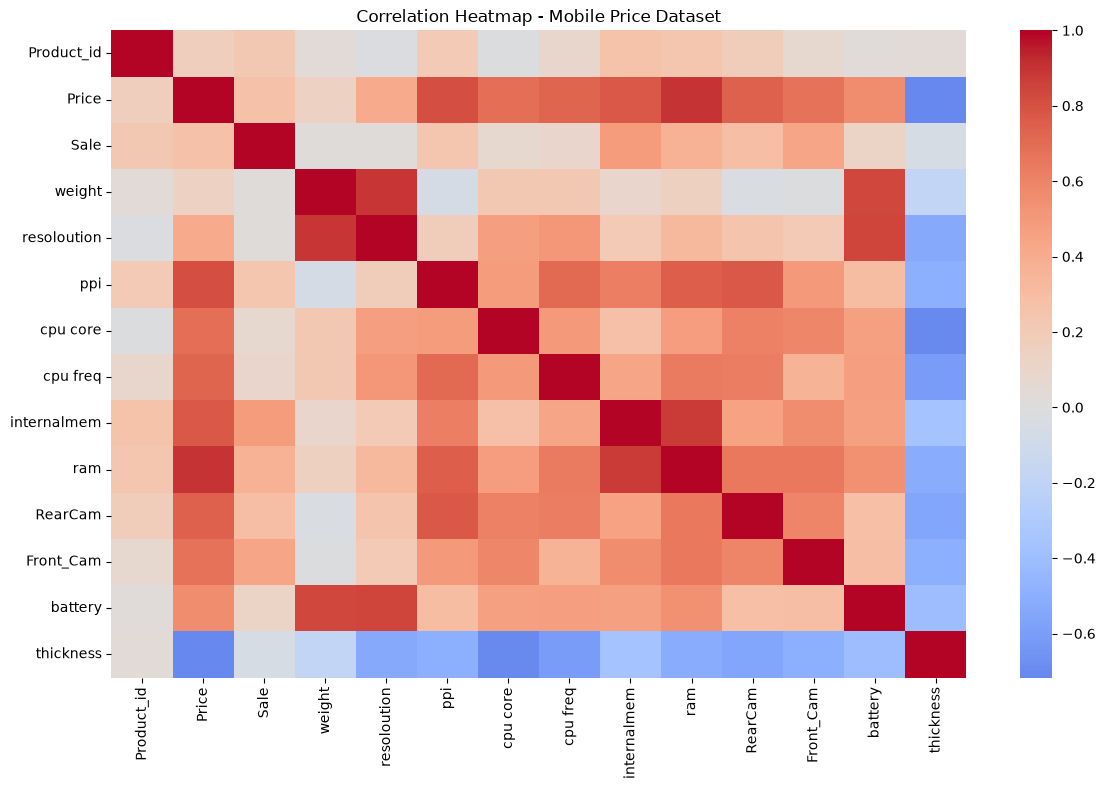

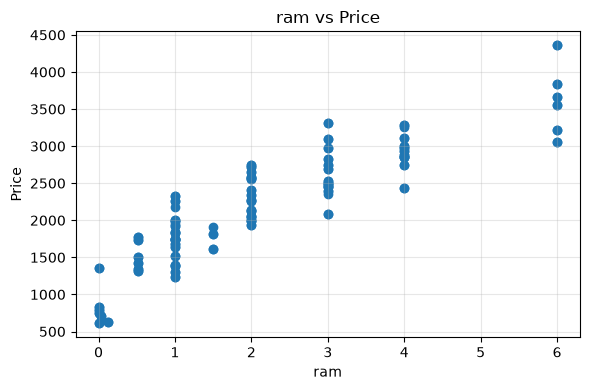

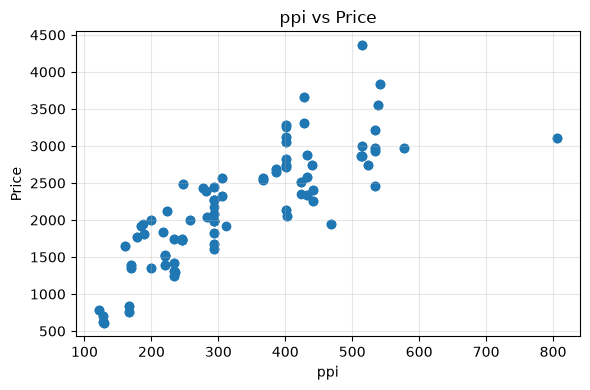

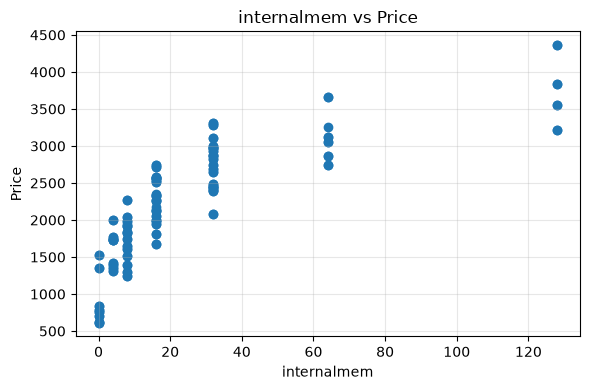

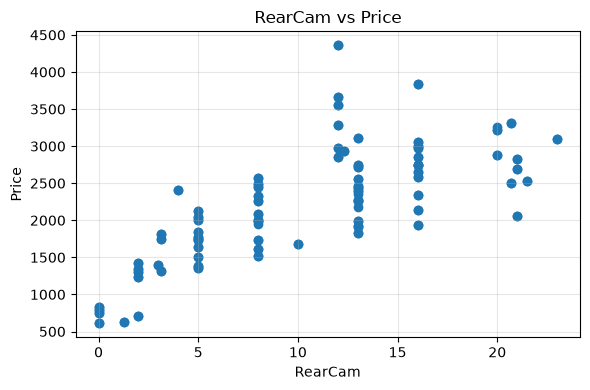

In [ ]:
#Task1
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("mobile_price_dataset.csv")

# 1. Dataset shape
print("===== DATASET SHAPE =====")
print(df.shape)

# 2. Column names
print("\n===== COLUMN NAMES =====")
print(df.columns.tolist())

# 3. Data types
print("\n===== DATA TYPES =====")
print(df.dtypes)

# 4. Missing values
print("\n===== MISSING VALUES =====")
print(df.isnull().sum())

# 5. Statistical summary
print("\n===== STATISTICAL SUMMARY =====")
print(df.describe().round(2))

# 6. Correlation with Price
corr = df.corr(numeric_only=True)
price_corr = corr["Price"].drop("Price").sort_values(
    key=abs, ascending=False
)

print("\n===== TOP 4 FEATURES CORRELATED WITH PRICE =====")
print(price_corr.head(4).round(4))

# 7. Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - Mobile Price Dataset")
plt.tight_layout()
plt.show()

# 8. Scatter plots for top 4 features
top4 = price_corr.head(4).index

for feature in top4:
    plt.figure(figsize=(6, 4))
    plt.scatter(df[feature], df["Price"])
    plt.xlabel(feature)
    plt.ylabel("Price")
    plt.title(f"{feature} vs Price")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
#Task2:
from sklearn.model_selection import train_test_split

# 2.1 Feature Selection
X = df.drop("Price", axis=1)
y = df["Price"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print("Price")

# 2.2 Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    train_size=0.80,
    random_state=42
)

print("\nTraining data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Features:
['Product_id', 'Sale', 'weight', 'resoloution', 'ppi', 'cpu core', 'cpu freq', 'internalmem', 'ram', 'RearCam', 'Front_Cam', 'battery', 'thickness']

Target:
Price

Training data shape: (128, 13)
Testing data shape: (33, 13)
Training target shape: (128,)
Testing target shape: (33,)


In [ ]:
#Task3
from sklearn.linear_model import LinearRegression

# 3.1 Create Linear Regression model
model = LinearRegression()

# 3.2 Train the model using training data
model.fit(X_train, y_train)

print("Linear Regression model created successfully.")
print("Model training completed successfully.")

Linear Regression model created successfully.
Model training completed successfully.


In [ ]:
#Task4:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 4.1 Predict on test data
y_pred = model.predict(X_test)

# 4.2 Model coefficients (slope)
print("Slope / Coefficients:")
print(model.coef_)

# Intercept
print("\nIntercept:")
print(model.intercept_)

# R² Score
r2 = r2_score(y_test, y_pred)
print("\nR² Score:", r2)

# Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error (MAE):", mae)

# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)

Slope / Coefficients:
[ 5.38073284e-02 -1.82887485e-02 -8.81592187e-01 -5.09440811e+01
  1.10822029e+00  4.93124037e+01  1.26691872e+02  5.26514379e+00
  1.00906852e+02  2.55238331e+00  7.68694997e+00  1.36214111e-01
 -7.01639389e+01]

Intercept:
1629.0911226213566

R² Score: 0.9593179111625745
Mean Absolute Error (MAE): 130.3153096103074
Mean Squared Error (MSE): 23062.229891749877


In [23]:
#Task5
import numpy as np

print("=" * 50)
print("5.1 MODEL EVALUATION")
print("=" * 50)

# Calculate metrics again
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)   # FIXED

print("R² Score :", round(r2, 4))
print("MAE      :", round(mae, 4))
print("MSE      :", round(mse, 4))
print("RMSE     :", round(rmse, 4))

if r2 >= 0.80:
    print("\nModel Performance: GOOD")
elif r2 >= 0.60:
    print("\nModel Performance: MODERATE")
else:
    print("\nModel Performance: NEEDS IMPROVEMENT")


print("\n" + "=" * 50)
print("5.2 INSIGHTS AND DISCUSSION")
print("=" * 50)

print("\n1. Correlation Analysis:")
for feature in top4:
    print(f"{feature}: {price_corr[feature]:.4f}")

print("\n2. Selected Features:")
print("The selected features provide useful information for predicting mobile prices.")

print("\n3. Slope / Coefficients:")
print("Positive coefficients indicate a positive relationship with Price.")
print("Negative coefficients indicate a negative relationship with Price.")

print("\n4. Intercept:")
print("The intercept represents the predicted Price when all input features are zero.")


print("\n" + "=" * 50)
print("5.3 POSSIBLE IMPROVEMENTS")
print("=" * 50)

print("1. Perform better feature selection.")
print("2. Apply feature engineering.")
print("3. Handle outliers properly.")
print("4. Use cross-validation.")
print("5. Try Random Forest or Gradient Boosting.")
print("6. Compare multiple regression models.")


print("\n" + "=" * 50)
print("FINAL CONCLUSION")
print("=" * 50)

print("The Linear Regression model was used to predict mobile prices.")
print("Correlation analysis helped identify important features related to Price.")
print("The model was evaluated using R² Score, MAE, MSE and RMSE.")
print("The model provides a useful baseline for mobile price prediction.")
print("Further improvement can be achieved using feature engineering")
print("and advanced machine-learning models.")

5.1 MODEL EVALUATION
R² Score : 0.9593
MAE      : 130.3153
MSE      : 23062.2299
RMSE     : 151.8625

Model Performance: GOOD

5.2 INSIGHTS AND DISCUSSION

1. Correlation Analysis:
ram: 0.8969
ppi: 0.8176
internalmem: 0.7767
RearCam: 0.7395

2. Selected Features:
The selected features provide useful information for predicting mobile prices.

3. Slope / Coefficients:
Positive coefficients indicate a positive relationship with Price.
Negative coefficients indicate a negative relationship with Price.

4. Intercept:
The intercept represents the predicted Price when all input features are zero.

5.3 POSSIBLE IMPROVEMENTS
1. Perform better feature selection.
2. Apply feature engineering.
3. Handle outliers properly.
4. Use cross-validation.
5. Try Random Forest or Gradient Boosting.
6. Compare multiple regression models.

FINAL CONCLUSION
The Linear Regression model was used to predict mobile prices.
Correlation analysis helped identify important features related to Price.
The model was eval